# Musica — Démo technique du pipeline ML

Ce notebook présente le pipeline complet de reconnaissance d'accords : audit du jeu de données, extraction Chroma-CQT, modèle CNN, réutilisation du cache d'entraînement, évaluation et prédictions sur des fichiers WAV.

L'objectif est de fournir une lecture rapide et visuelle du projet. Les cellules réutilisent le modèle en cache quand la signature du run existe déjà, afin d'éviter un réentraînement inutile pendant la démonstration.


## 0. Initialisation

On charge les classes du projet et les helpers de visualisation du fichier `notebook_helpers.py`.


In [1]:
from pathlib import Path
import sys

from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from musica.modeling import (
    ChordEvaluator,
    ChordPredictor,
    ChordTrainer,
    FeatureExtractor,
    MusicaConfig,
    prepare_data,
)
from notebook_helpers import (
    dataset_audit,
    display_model_summary,
    display_prediction_summary,
    evaluate_predictions,
    format_int,
    plot_audio_and_feature,
    plot_confusion_matrix,
    plot_dataset_overview,
    plot_error_analysis,
    plot_example_predictions,
    plot_split_distribution,
    plot_test_metrics,
    plot_training_curves,
    setup_notebook_style,
    show_classification_report_dataframe,
    show_dataset_summary,
    show_table,
)

setup_notebook_style()


## 1. Configuration

La configuration vient de `musica.toml`. Pour cette démo, `force_retrain` est maintenu à `False` afin de privilégier le modèle déjà en cache.


2026-07-10 11:30:00.413 | INFO     | musica.config:load:230 - Chargement de la configuration: musica.toml


2026-07-10 11:30:00.414 | INFO     | musica.config:load:233 - Configuration chargee: epochs=60, batch_size=32, lr=0.001, force_retrain=False


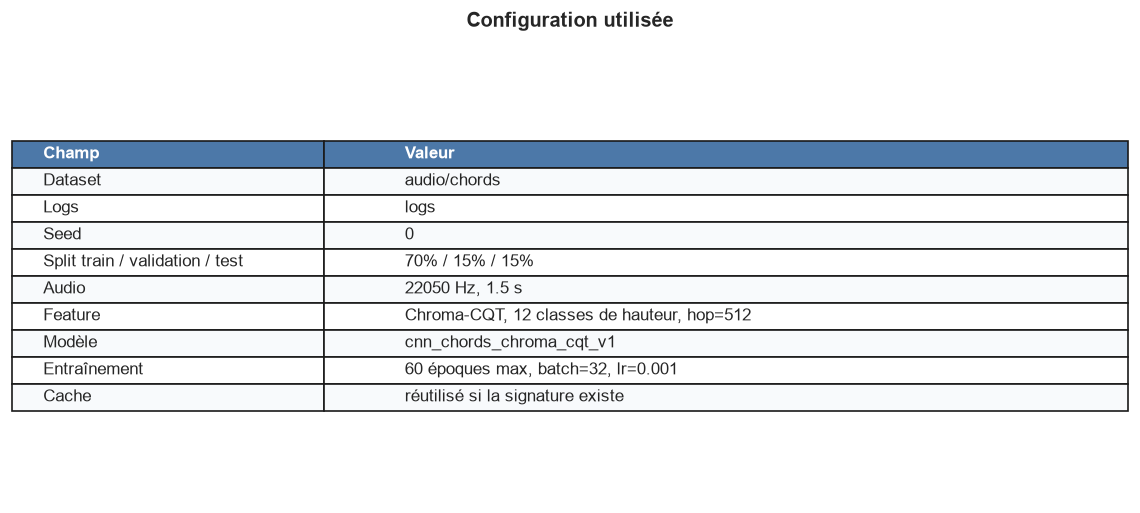

In [2]:
config = MusicaConfig.load()
if config.force_retrain:
    config = config.model_copy(
        update={"training": config.training.model_copy(update={"force_retrain": False})}
    )

dataset_dir = config.resolve_path(PROJECT_ROOT, config.dataset_dir)
logs_dir = config.resolve_path(PROJECT_ROOT, config.logs_dir)

show_table(
    "Configuration utilisée",
    [
        ("Dataset", dataset_dir.relative_to(PROJECT_ROOT)),
        ("Logs", logs_dir.relative_to(PROJECT_ROOT)),
        ("Seed", config.seed),
        ("Split train / validation / test", f"{1 - config.val_ratio - config.test_ratio:.0%} / {config.val_ratio:.0%} / {config.test_ratio:.0%}"),
        ("Audio", f"{config.sample_rate} Hz, {config.target_duration:.1f} s"),
        ("Feature", f"Chroma-CQT, {config.n_chroma} classes de hauteur, hop={config.hop_length}"),
        ("Modèle", config.model_architecture),
        ("Entraînement", f"{config.epochs} époques max, batch={config.batch_size}, lr={config.learning_rate}"),
        ("Cache", "réutilisé si la signature existe"),
    ],
)

## 2. Préparation et audit du dataset

La préparation découvre les WAV, crée les splits stratifiés et extrait les features Chroma-CQT. Les graphiques ci-dessous vérifient rapidement le volume, la provenance et l'équilibre du dataset.


2026-07-10 11:30:00.501 | INFO     | musica.modeling.preparation:prepare_data:15 - Preparation des donnees


2026-07-10 11:30:00.501 | INFO     | musica.modeling.dataset:discover:34 - Recherche des fichiers WAV dans /Users/raharison/docs/projects/musica/audio/chords


2026-07-10 11:30:00.531 | INFO     | musica.modeling.dataset:discover:45 - Dataset decouvert: 3924 fichiers audio, 36 classes


2026-07-10 11:30:00.531 | INFO     | musica.modeling.dataset:split:56 - Creation du split stratifie: val_ratio=0.15, test_ratio=0.15, seed=0


2026-07-10 11:30:00.584 | INFO     | musica.modeling.dataset:split:86 - Split pret: train=2772, validation=576, test=576


...

2026-07-10 11:30:36.604 | INFO     | musica.modeling.features:load_features:51 - Features extraites: 250/576


2026-07-10 11:30:39.134 | INFO     | musica.modeling.features:load_features:51 - Features extraites: 500/576


2026-07-10 11:30:39.927 | INFO     | musica.modeling.features:load_features:51 - Features extraites: 576/576


2026-07-10 11:30:39.928 | INFO     | musica.modeling.features:load_features:53 - Features pretes: shape=(576, 65, 12, 1)


2026-07-10 11:30:39.928 | INFO     | musica.modeling.preparation:prepare_data:25 - Preparation des donnees terminee


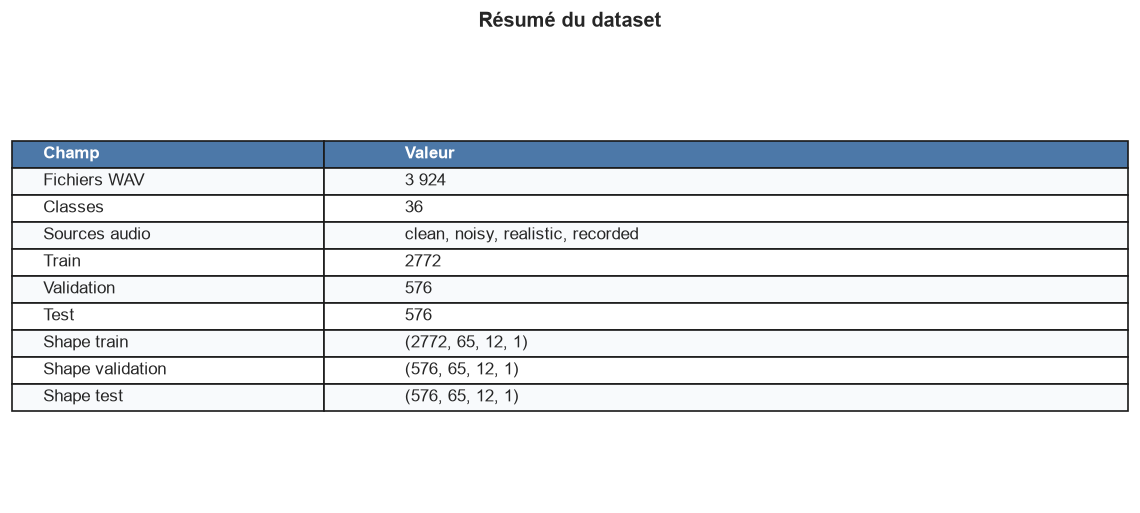

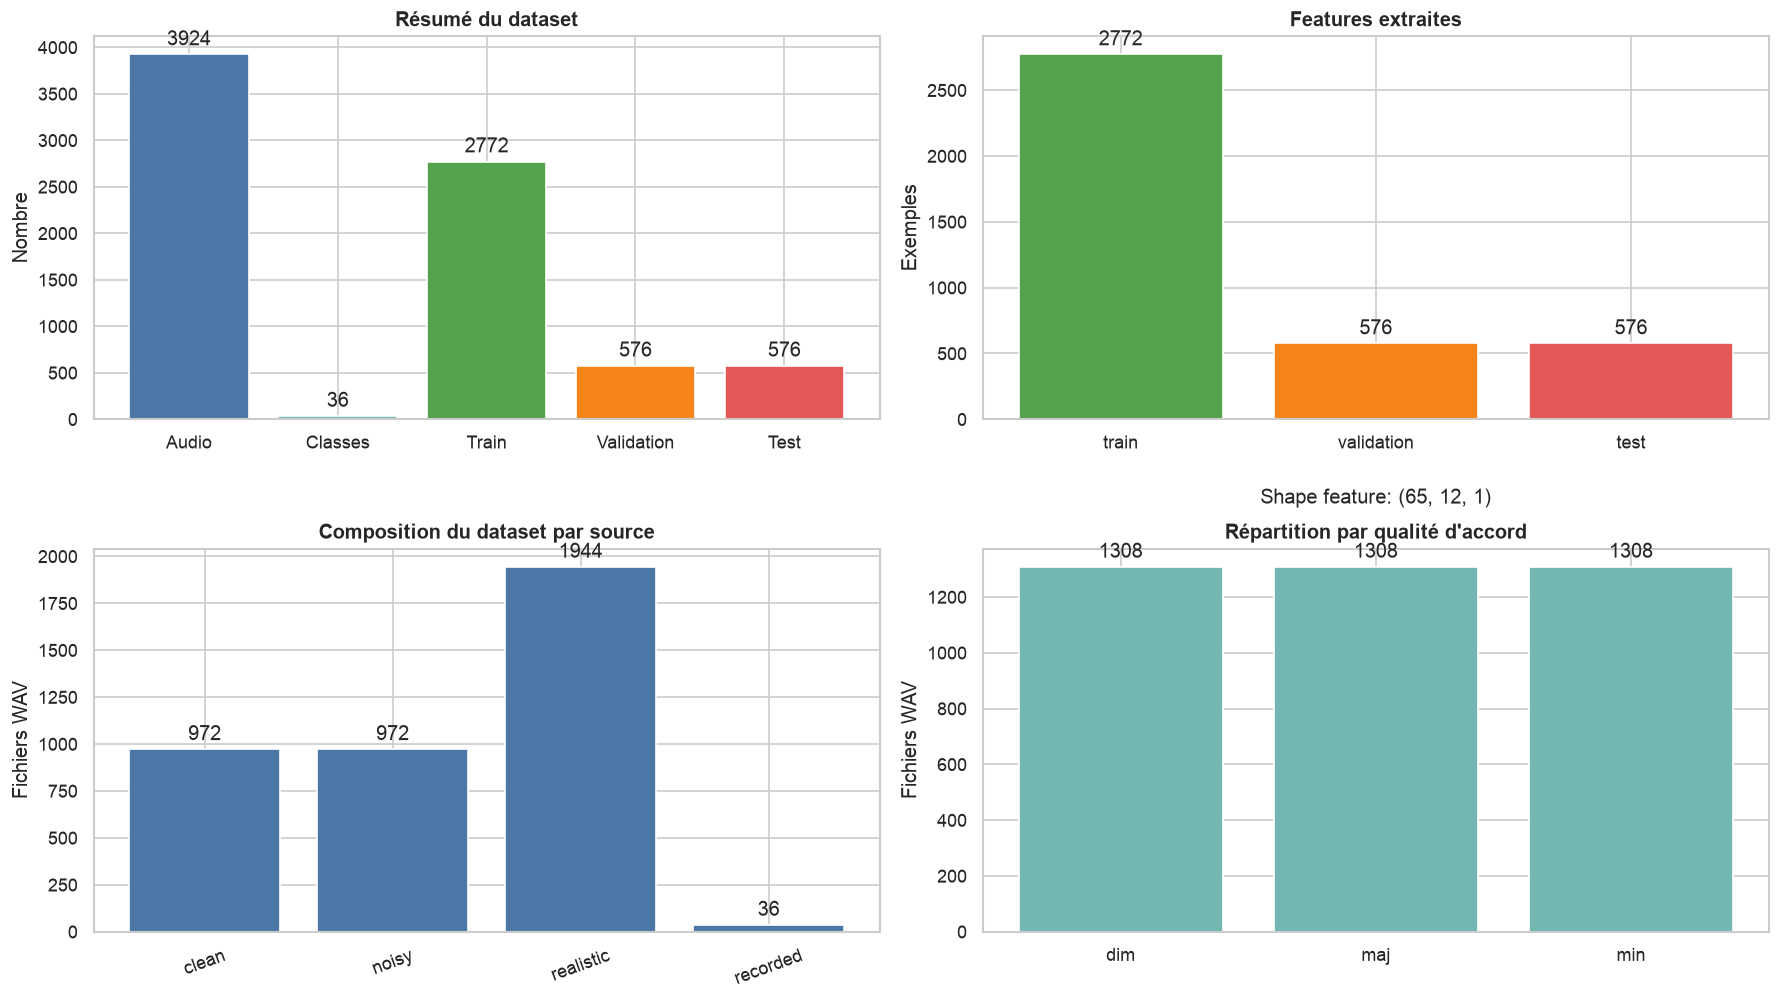

Le dataset contient **3 924 fichiers WAV** et **36 classes**. La présence de plusieurs sources aide à tester le modèle sur des variantes propres, bruitées, réalistes ou enregistrées.

In [3]:
prepared = prepare_data(config)
audit = dataset_audit(prepared)
dataset = audit["dataset"]
split_paths = audit["split_paths"]
split_sizes = audit["split_sizes"]

show_dataset_summary(prepared, audit)
plot_dataset_overview(prepared, audit)

display(Markdown(
    f"Le dataset contient **{format_int(len(dataset.audio_paths))} fichiers WAV** et **{len(dataset.labels)} classes**. "
    "La présence de plusieurs sources aide à tester le modèle sur des variantes propres, bruitées, réalistes ou enregistrées."
))


## 3. Vérification des splits

Les splits doivent rester équilibrés par classe pour éviter qu'une classe soit plus facile ou plus difficile uniquement à cause de sa représentation dans train, validation ou test.


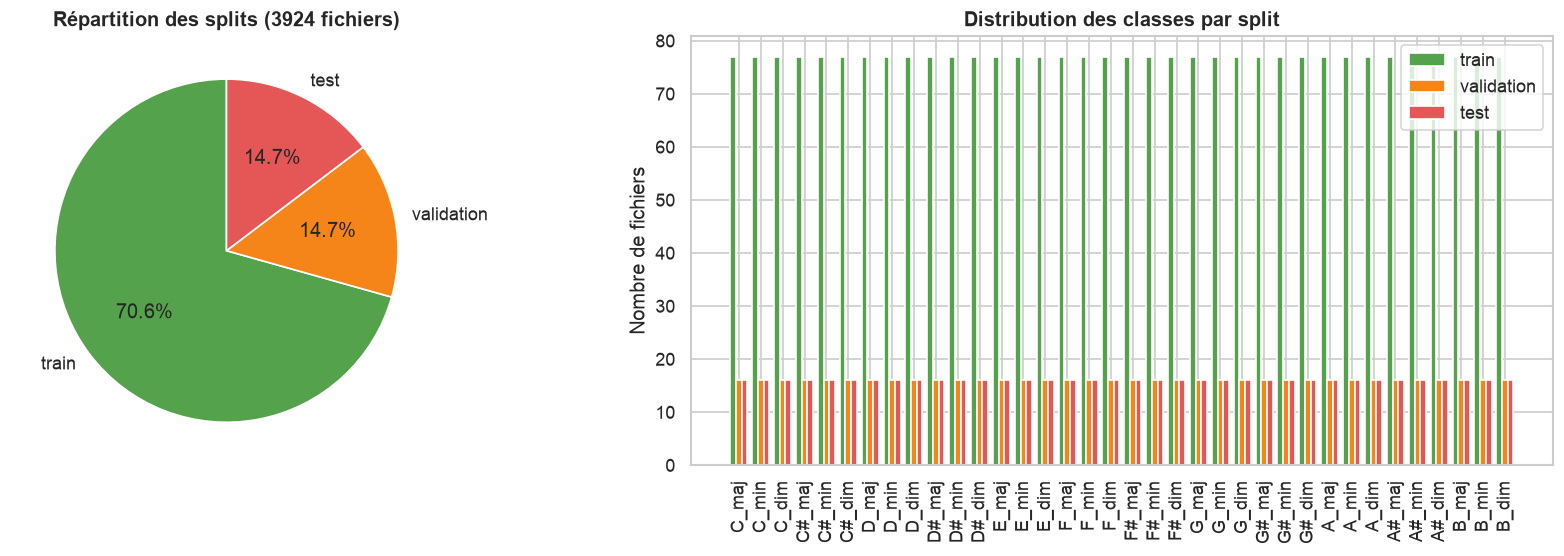

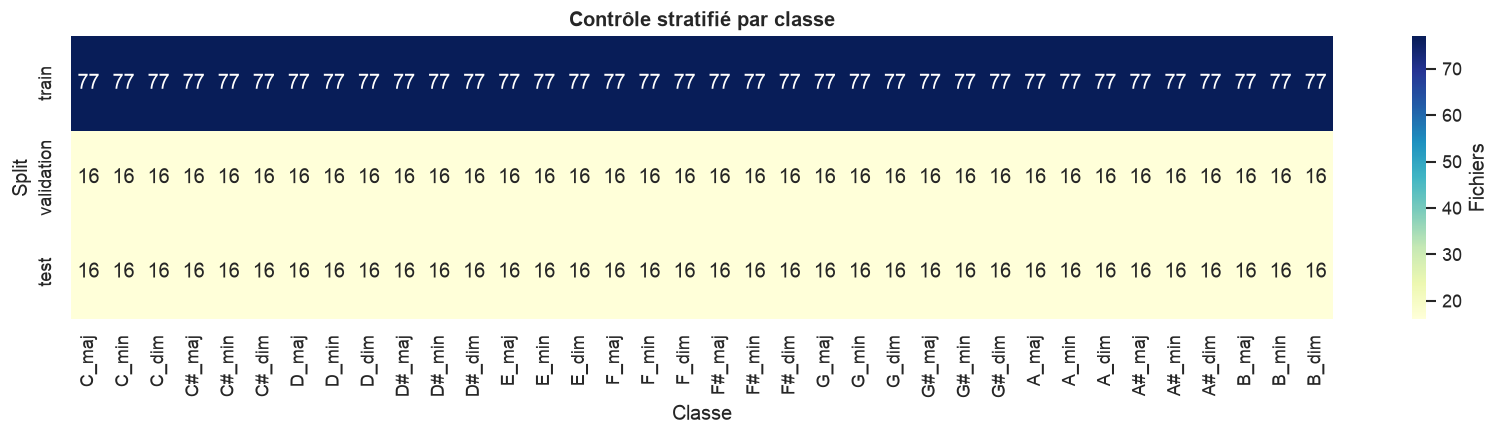

La stratification conserve des volumes proches pour chaque accord dans les trois splits. Cette condition rend l'accuracy globale plus interprétable.

In [4]:
plot_split_distribution(dataset, audit)

display(Markdown(
    "La stratification conserve des volumes proches pour chaque accord dans les trois splits. "
    "Cette condition rend l'accuracy globale plus interprétable."
))


## 4. Exemple audio et feature Chroma-CQT

Le modèle ne reçoit pas directement l'onde audio brute. Chaque fichier est converti en Chroma-CQT, une représentation qui regroupe l'énergie par classe de hauteur chromatique.


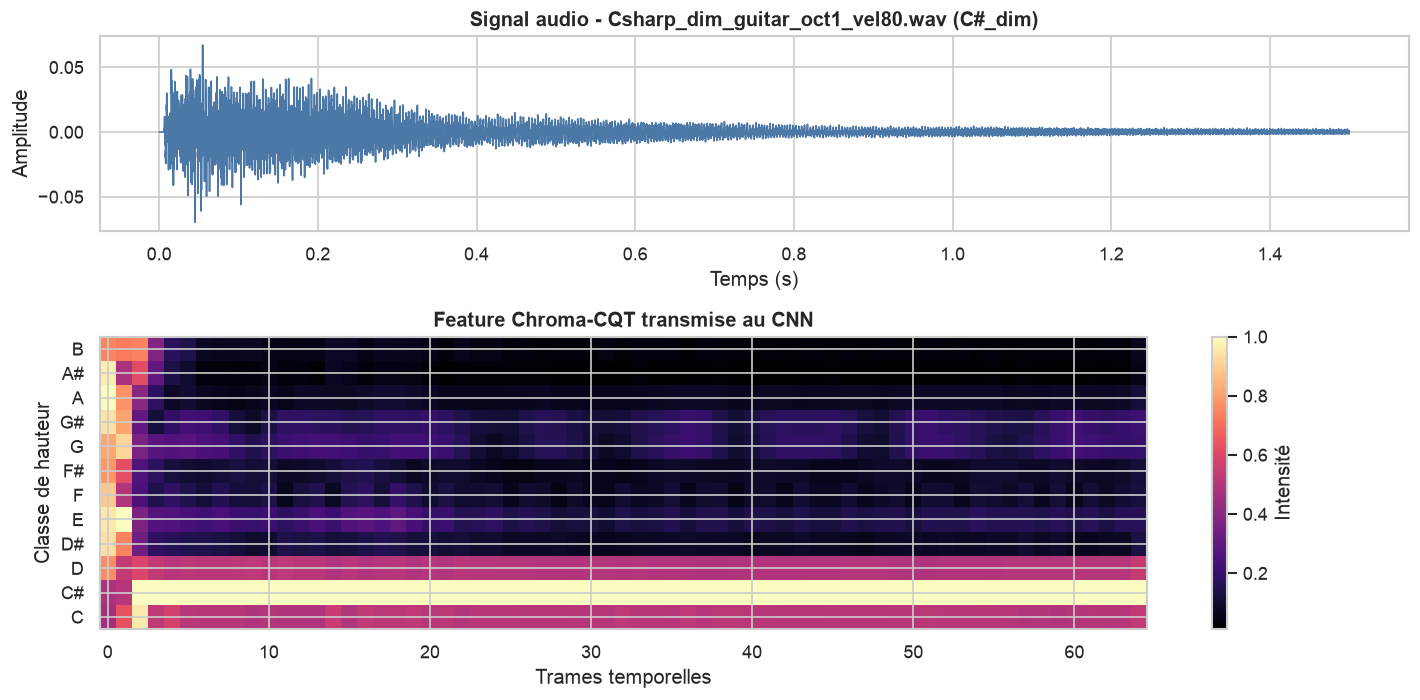

Le Chroma-CQT met l'accent sur les relations harmoniques entre notes. C'est adapté aux accords isolés, où la structure de hauteur compte davantage que la forme brute de l'onde.

In [5]:
example_index = 0
example_path = prepared.split.train_paths[example_index]
example_label = dataset.label_from_path(example_path)
example_feature = prepared.x_train[example_index, :, :, 0]

plot_audio_and_feature(example_path, example_feature, example_label, config)

display(Markdown(
    "Le Chroma-CQT met l'accent sur les relations harmoniques entre notes. "
    "C'est adapté aux accords isolés, où la structure de hauteur compte davantage que la forme brute de l'onde."
))


## 5. Modèle et cache d'entraînement

Le modèle CNN est entraîné ou chargé depuis le cache selon la signature calculée à partir du dataset, du split et des hyperparamètres. Avec le cache présent, cette cellule recharge le meilleur modèle sans relancer les 60 époques.


2026-07-10 11:30:40.914 | INFO     | musica.modeling.training:signature:159 - Signature du run: bddbd88ac5d1


2026-07-10 11:30:42.700 | INFO     | musica.modeling.training:load_cached_model:166 - Verification du cache modele: /Users/raharison/docs/projects/musica/logs/models/bddbd88ac5d1/best_model.keras


2026-07-10 11:30:42.700 | INFO     | musica.modeling.training:load_cached_model:168 - Cache hit: chargement de /Users/raharison/docs/projects/musica/logs/models/bddbd88ac5d1/best_model.keras


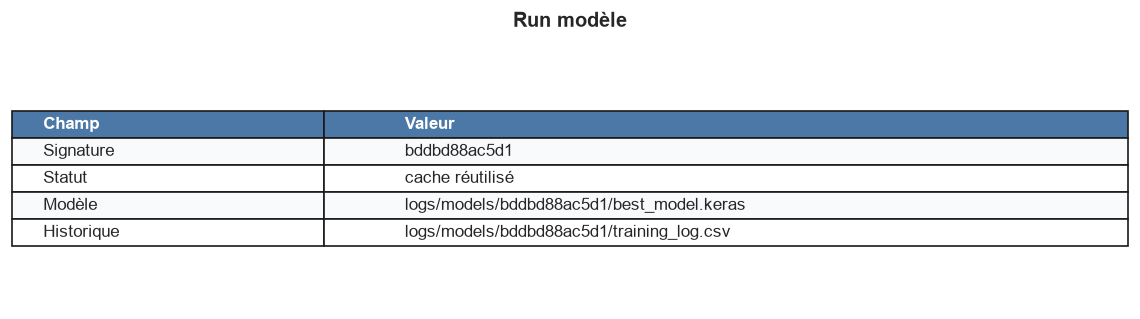

Le cache rend la démonstration reproductible et rapide. Si les données ou les hyperparamètres changent, la signature change aussi et un nouveau run peut être produit.

In [6]:
trainer = ChordTrainer(config, dataset)
training = trainer.train_or_load(prepared)

show_table(
    "Run modèle",
    [
        ("Signature", training.signature),
        ("Statut", "cache réutilisé" if training.cache_hit else "modèle entraîné"),
        ("Modèle", training.model_path.relative_to(PROJECT_ROOT)),
        ("Historique", training.history_log_path.relative_to(PROJECT_ROOT)),
    ],
)

display(Markdown(
    "Le cache rend la démonstration reproductible et rapide. "
    "Si les données ou les hyperparamètres changent, la signature change aussi et un nouveau run peut être produit."
))


## 6. Architecture du modèle

La vue ci-dessous remet le détail technique du modèle chargé : normalisation, blocs convolutionnels, pooling, dropout et couche softmax finale.


In [7]:
display_model_summary(training.model)


Model: "cnn_chords"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 65, 12, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 65, 12, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 65, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 12, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 12, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,001 (820.32 KB)

 Trainable params: 69,892 (273.02 KB)

 Non-trainable params: 323 (1.27 KB)

 Optimizer params: 139,786 (546.04 KB)

## 7. Courbes d'entraînement

Les courbes permettent de vérifier la convergence et l'écart entre entraînement et validation. Les changements de learning rate sont marqués pour repérer les phases de stabilisation.


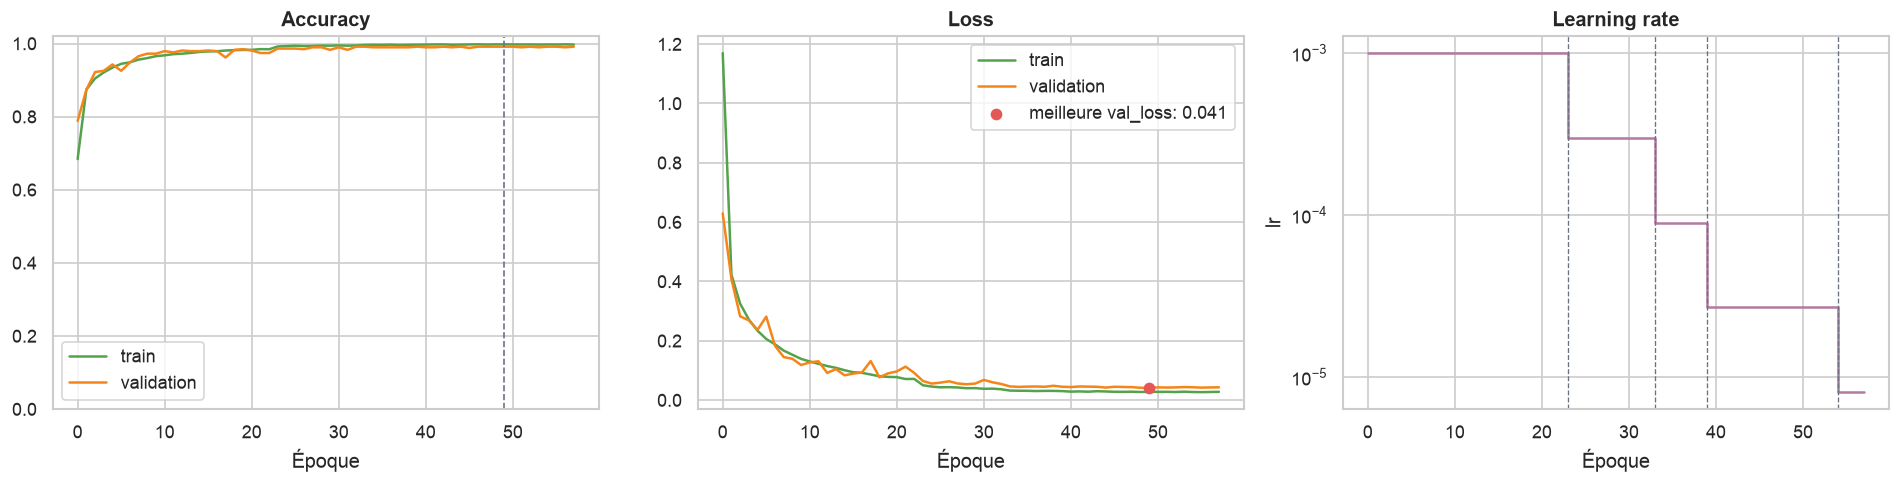

La meilleure validation loss est atteinte à l'époque **49** (`val_loss=0.041`, `val_accuracy=0.991`). Les courbes montrent une convergence stable avec un écart train/validation limité.

In [8]:
training_curve_summary = plot_training_curves(training.history_log_path)

display(Markdown(
    f"La meilleure validation loss est atteinte à l'époque **{training_curve_summary['best_epoch']}** "
    f"(`val_loss={training_curve_summary['best_val_loss']:.3f}`, "
    f"`val_accuracy={training_curve_summary['best_val_accuracy']:.3f}`). "
    "Les courbes montrent une convergence stable avec un écart train/validation limité."
))


## 8. Évaluation sur le test

On mesure la performance finale sur le split test, puis on regarde les erreurs par classe. La matrice normalisée montre les confusions en pourcentage plutôt qu'en nombre brut.


2026-07-10 11:30:43.109 | INFO     | musica.modeling.evaluation:evaluate:30 - Evaluation sur le test: 576 exemples


2026-07-10 11:30:43.529 | INFO     | musica.modeling.evaluation:evaluate:40 - Evaluation terminee: accuracy=0.9948, loss=0.0380, f1_macro=0.9948


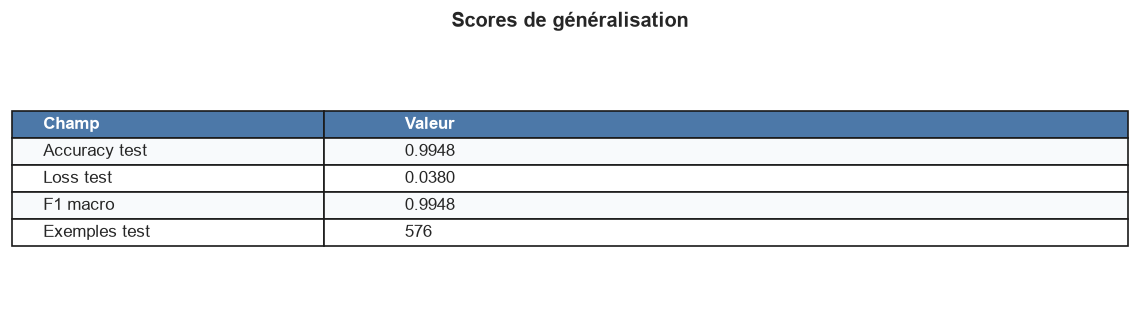

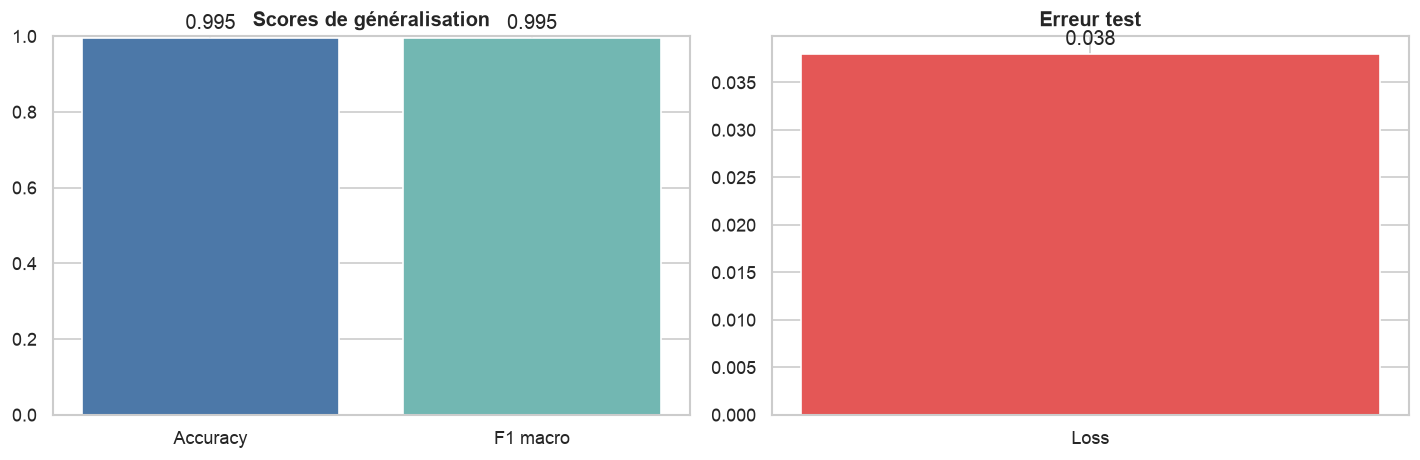

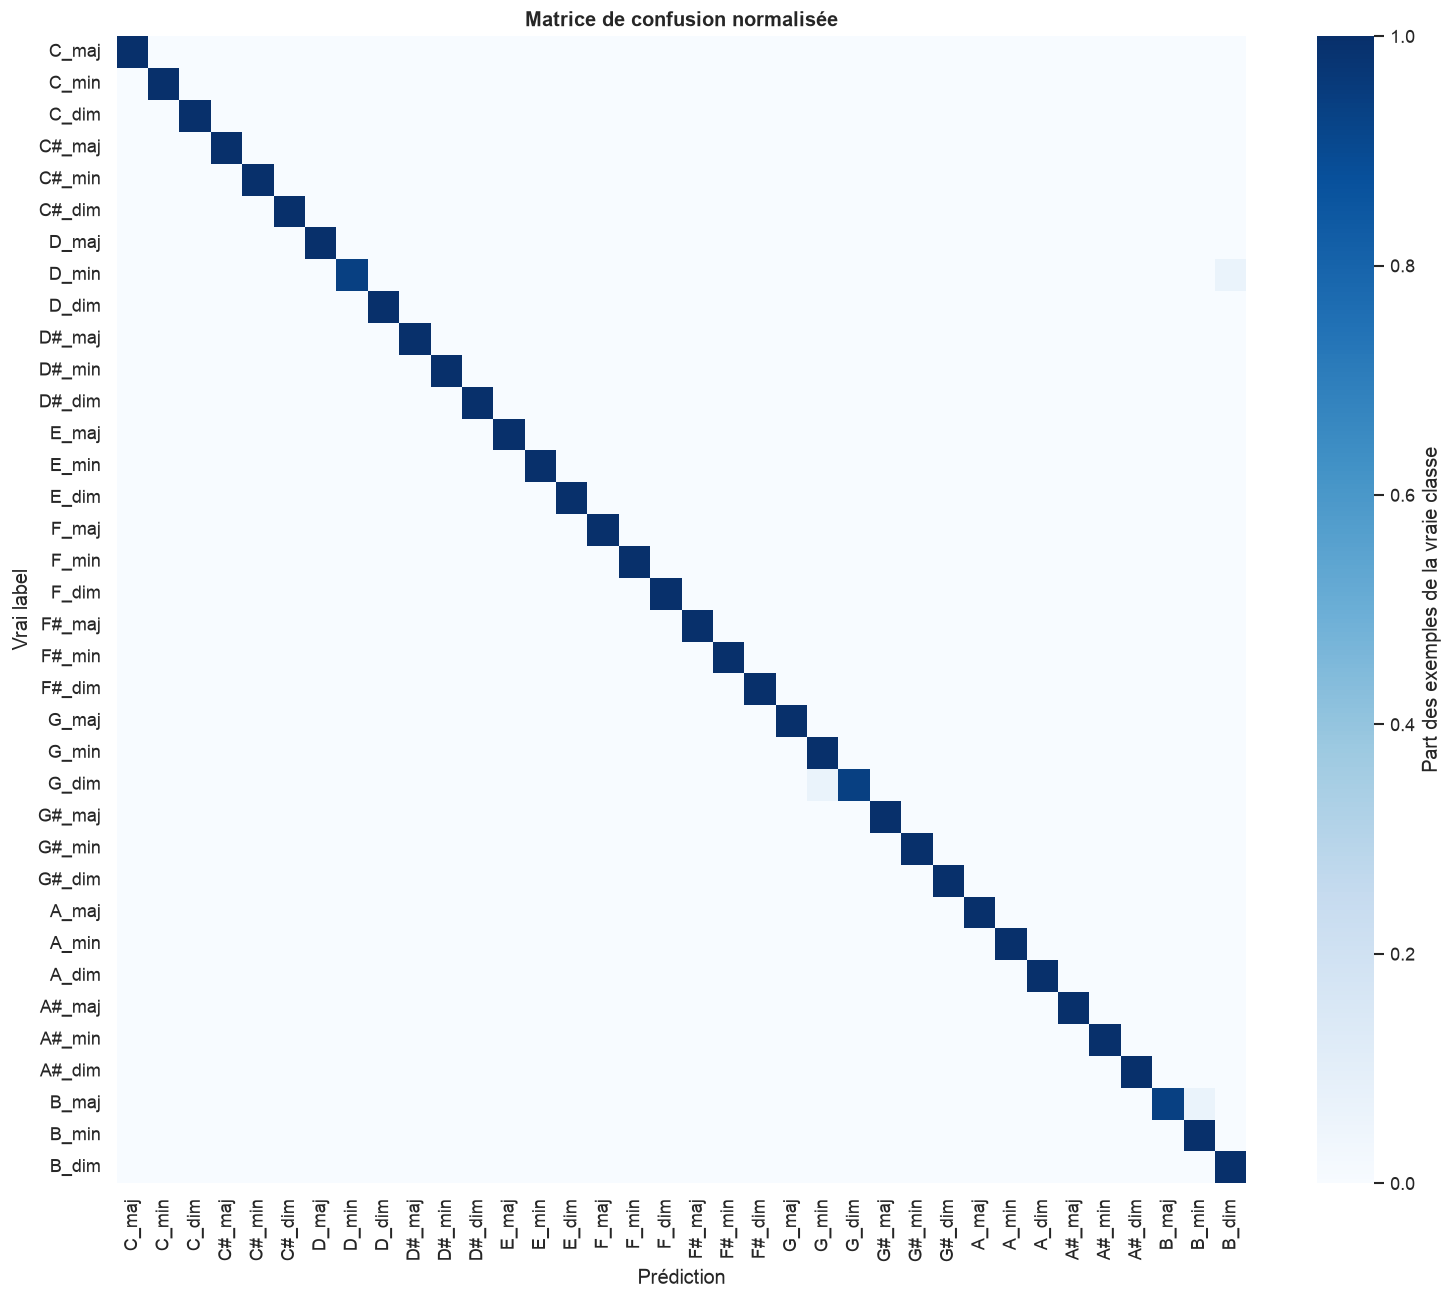

Le modèle atteint **99.48% d'accuracy** et **99.48% de F1 macro** sur le test. Le F1 macro est important ici, car il donne le même poids à chaque classe d'accord.

In [9]:
evaluator = ChordEvaluator()
evaluation = evaluator.evaluate(training.model, prepared.x_test, prepared.y_test, dataset.labels)
prediction_analysis = evaluate_predictions(training.model, prepared, dataset.labels)

show_table(
    "Scores de généralisation",
    [
        ("Accuracy test", f"{evaluation.test_accuracy:.4f}"),
        ("Loss test", f"{evaluation.test_loss:.4f}"),
        ("F1 macro", f"{evaluation.f1_macro:.4f}"),
        ("Exemples test", len(prepared.y_test)),
    ],
)
plot_test_metrics(evaluation)
plot_confusion_matrix(dataset.labels, prediction_analysis["cm_normalized"])

display(Markdown(
    f"Le modèle atteint **{evaluation.test_accuracy:.2%} d'accuracy** et **{evaluation.f1_macro:.2%} de F1 macro** sur le test. "
    "Le F1 macro est important ici, car il donne le même poids à chaque classe d'accord."
))


## 9. Rapport de classification

Le DataFrame complète les graphiques avec la précision, le rappel, le F1-score et le support de chaque classe.


In [10]:
classification_report_df = show_classification_report_dataframe(prediction_analysis["report"])
classification_report_df


,precision,recall,f1-score,support
C_maj,1.000,1.000,1.000,16
C_min,1.000,1.000,1.000,16
C_dim,1.000,1.000,1.000,16
C#_maj,1.000,1.000,1.000,16
C#_min,1.000,1.000,1.000,16
C#_dim,1.000,1.000,1.000,16
D_maj,1.000,1.000,1.000,16
D_min,1.000,0.938,0.968,16
D_dim,1.000,1.000,1.000,16
D#_maj,1.000,1.000,1.000,16


,precision,recall,f1-score,support
C_maj,1.000,1.000,1.000,16
C_min,1.000,1.000,1.000,16
C_dim,1.000,1.000,1.000,16
C#_maj,1.000,1.000,1.000,16
C#_min,1.000,1.000,1.000,16
C#_dim,1.000,1.000,1.000,16
D_maj,1.000,1.000,1.000,16
D_min,1.000,0.938,0.968,16
D_dim,1.000,1.000,1.000,16
D#_maj,1.000,1.000,1.000,16


## 10. Analyse des erreurs

Même avec de très bons scores globaux, il faut regarder quelles classes se confondent. Cette section affiche les classes les plus faibles et les principales confusions hors diagonale.


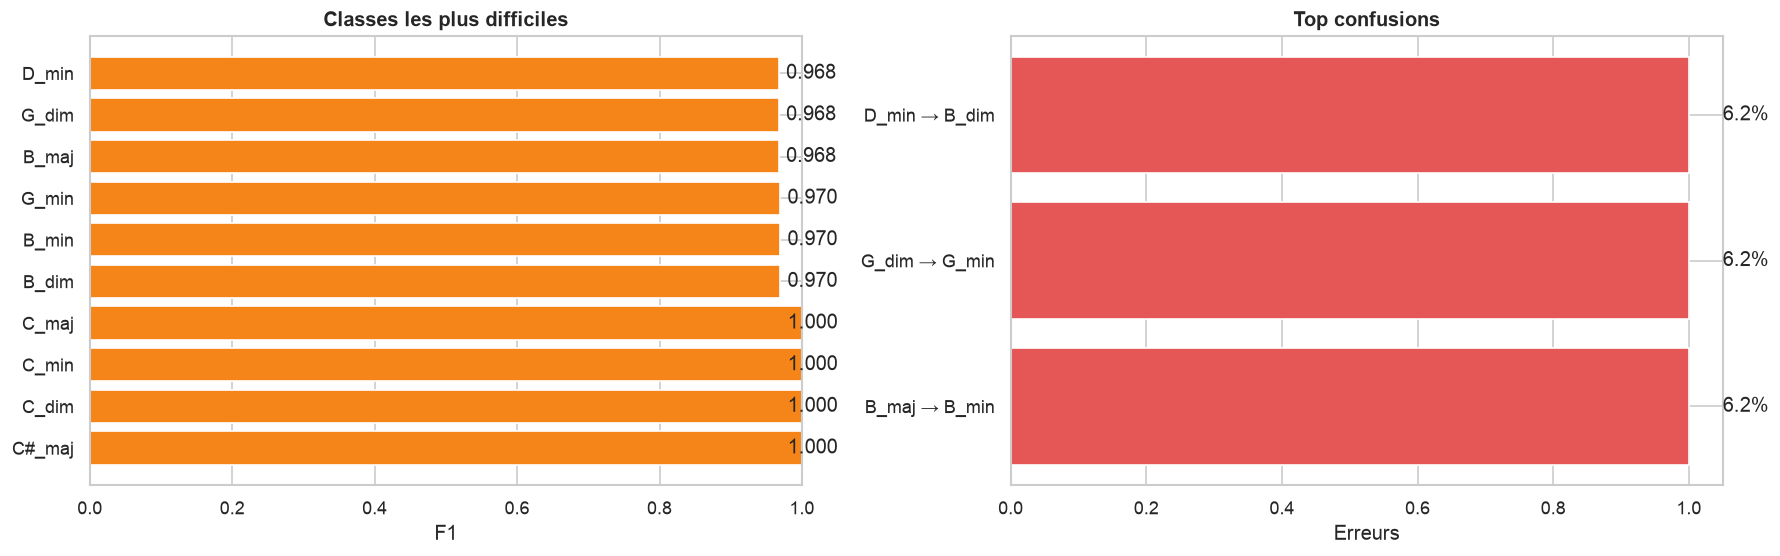

Les confusions restantes sont peu nombreuses. Elles indiquent les classes à inspecter en priorité si le dataset est enrichi avec plus d'enregistrements réels.

In [11]:
plot_error_analysis(
    dataset.labels,
    prediction_analysis["report"],
    prediction_analysis["cm"],
    prediction_analysis["cm_normalized"],
)
display(Markdown(
    "Les confusions restantes sont peu nombreuses. "
    "Elles indiquent les classes à inspecter en priorité si le dataset est enrichi avec plus d'enregistrements réels."
))

## 11. Prédictions sur des exemples WAV

On applique le modèle à quelques fichiers du dossier `examples/` et on affiche le top-k des classes les plus probables.


2026-07-10 11:30:44.050 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/E_maj.wav


2026-07-10 11:30:44.221 | INFO     | musica.modeling.prediction:predict:29 - Prediction de l'audio: /Users/raharison/docs/projects/musica/examples/G_maj.wav


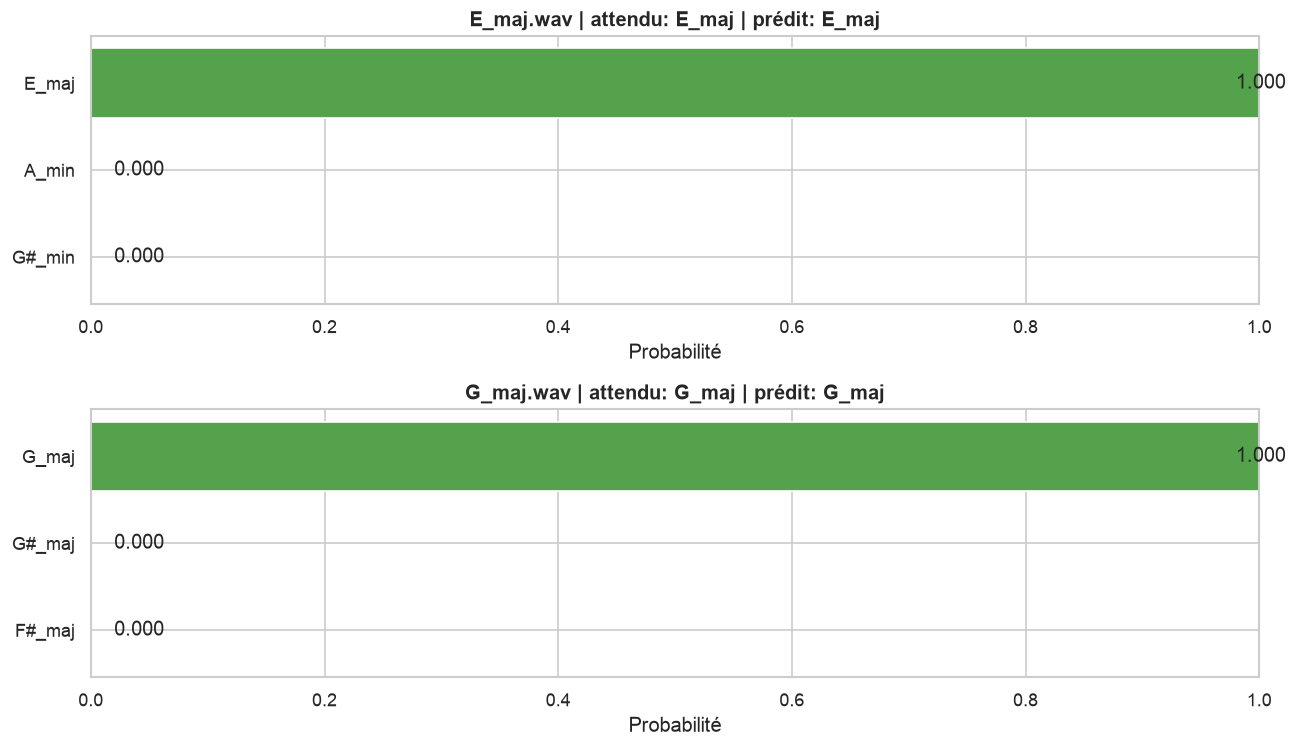

Résumé des prédictions :
- `E_maj.wav` : attendu `E_maj`, prédit `E_maj` avec 100.0%
- `G_maj.wav` : attendu `G_maj`, prédit `G_maj` avec 100.0%

In [12]:
predictor = ChordPredictor(config, FeatureExtractor(config, dataset), dataset.labels)
example_audio_files = config.examples.audio_paths(PROJECT_ROOT)

prediction_summaries = plot_example_predictions(
    predictor,
    training.model,
    dataset,
    example_audio_files,
)
display_prediction_summary(prediction_summaries)


## 12. Lecture critique et limites

- Les scores sont élevés sur le split test, mais le dataset reste fortement contrôlé : beaucoup d'exemples viennent de génération ou d'augmentation audio.
- La généralisation vers des prises réelles, des instruments inconnus ou des accords joués dans un contexte musical continu doit être validée avec davantage d'audio externe.
- La représentation Chroma-CQT est pertinente pour des accords isolés, mais elle ne traite pas encore les transitions temporelles complexes d'un morceau complet.
- Les prochaines améliorations utiles seraient d'ajouter plus d'enregistrements réels, de suivre les métriques par source audio et de tester le modèle sur des jeux externes annotés.
